# Mobile Price Classification

Exploratory analysis and multiclass classification of mobile-phone price ranges using Decision Tree, Random Forest, and SVM models. This public version includes small code-quality fixes in the model-specific evaluation cells and preserves the original analysis structure.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings("ignore")
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
train

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [4]:
test

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,1700,1,1.9,0,0,1,54,0.5,170,...,17,644,913,2121,14,8,15,1,1,0
996,997,609,0,1.8,1,0,0,13,0.9,186,...,2,1152,1632,1933,8,1,19,0,1,1
997,998,1185,0,1.4,0,1,1,8,0.5,80,...,12,477,825,1223,5,0,14,1,0,0
998,999,1533,1,0.5,1,0,0,50,0.4,171,...,12,38,832,2509,15,11,6,0,1,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1000 non-null   int64  
 1   battery_power  1000 non-null   int64  
 2   blue           1000 non-null   int64  
 3   clock_speed    1000 non-null   float64
 4   dual_sim       1000 non-null   int64  
 5   fc             1000 non-null   int64  
 6   four_g         1000 non-null   int64  
 7   int_memory     1000 non-null   int64  
 8   m_dep          1000 non-null   float64
 9   mobile_wt      1000 non-null   int64  
 10  n_cores        1000 non-null   int64  
 11  pc             1000 non-null   int64  
 12  px_height      1000 non-null   int64  
 13  px_width       1000 non-null   int64  
 14  ram            1000 non-null   int64  
 15  sc_h           1000 non-null   int64  
 16  sc_w           1000 non-null   int64  
 17  talk_time      1000 non-null   int64  
 18  three_g  

In [7]:
train.describe(include="all")

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [8]:
test.describe(include="all")

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,1248.510000,0.516000,1.540900,0.517000,4.593000,0.487000,33.652000,0.517500,139.51100,...,10.054000,627.121000,1239.774000,2138.998000,11.995000,5.316000,11.085000,0.756000,0.50000,0.507000
std,288.819436,432.458227,0.499994,0.829268,0.499961,4.463325,0.500081,18.128694,0.280861,34.85155,...,6.095099,432.929699,439.670981,1088.092278,4.320607,4.240062,5.497636,0.429708,0.50025,0.500201
min,1.000000,500.000000,0.000000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.00000,...,0.000000,0.000000,501.000000,263.000000,5.000000,0.000000,2.000000,0.000000,0.00000,0.000000
25%,250.750000,895.000000,0.000000,0.700000,0.000000,1.000000,0.000000,18.000000,0.300000,109.75000,...,5.000000,263.750000,831.750000,1237.250000,8.000000,2.000000,6.750000,1.000000,0.00000,0.000000
50%,500.500000,1246.500000,1.000000,1.500000,1.000000,3.000000,0.000000,34.500000,0.500000,139.00000,...,10.000000,564.500000,1250.000000,2153.500000,12.000000,5.000000,11.000000,1.000000,0.50000,1.000000
75%,750.250000,1629.250000,1.000000,2.300000,1.000000,7.000000,1.000000,49.000000,0.800000,170.00000,...,16.000000,903.000000,1637.750000,3065.500000,16.000000,8.000000,16.000000,1.000000,1.00000,1.000000
max,1000.000000,1999.000000,1.000000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.00000,...,20.000000,1907.000000,1998.000000,3989.000000,19.000000,18.000000,20.000000,1.000000,1.00000,1.000000


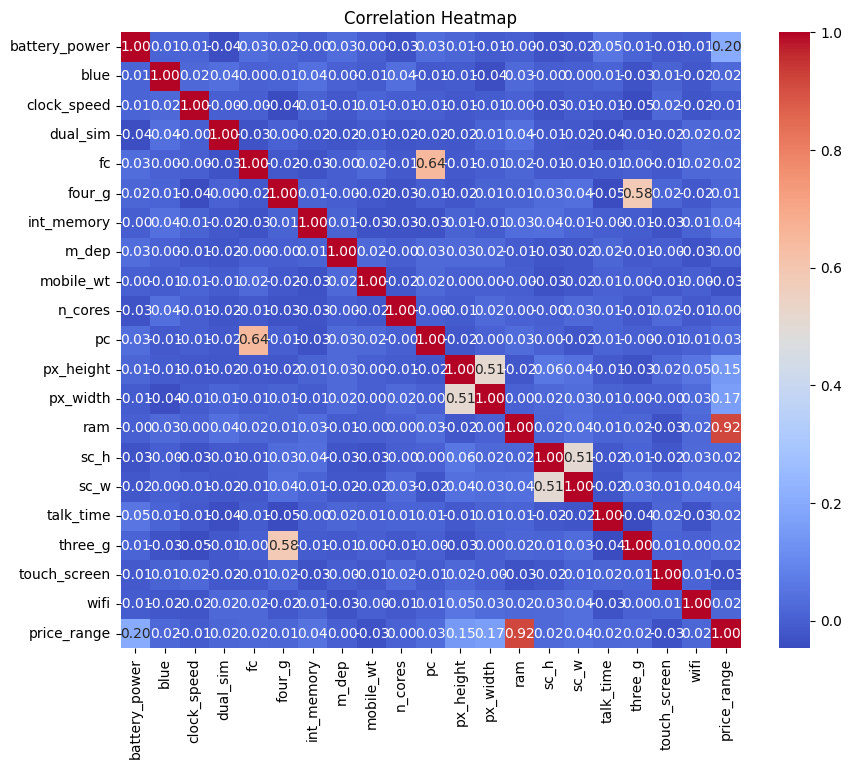

In [9]:
num_cols = ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc',
             'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 
             'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time',
             'three_g', 'touch_screen', 'wifi','price_range']

temp = train[num_cols].copy()

scaler = StandardScaler()
temp_scaled = pd.DataFrame(scaler.fit_transform(temp), columns=num_cols)

plt.figure(figsize=(10,8))
sns.heatmap(temp_scaled.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Drew a correlation map to visualize relationships between variables.
As we can see ram has a very strong correlation with price_range

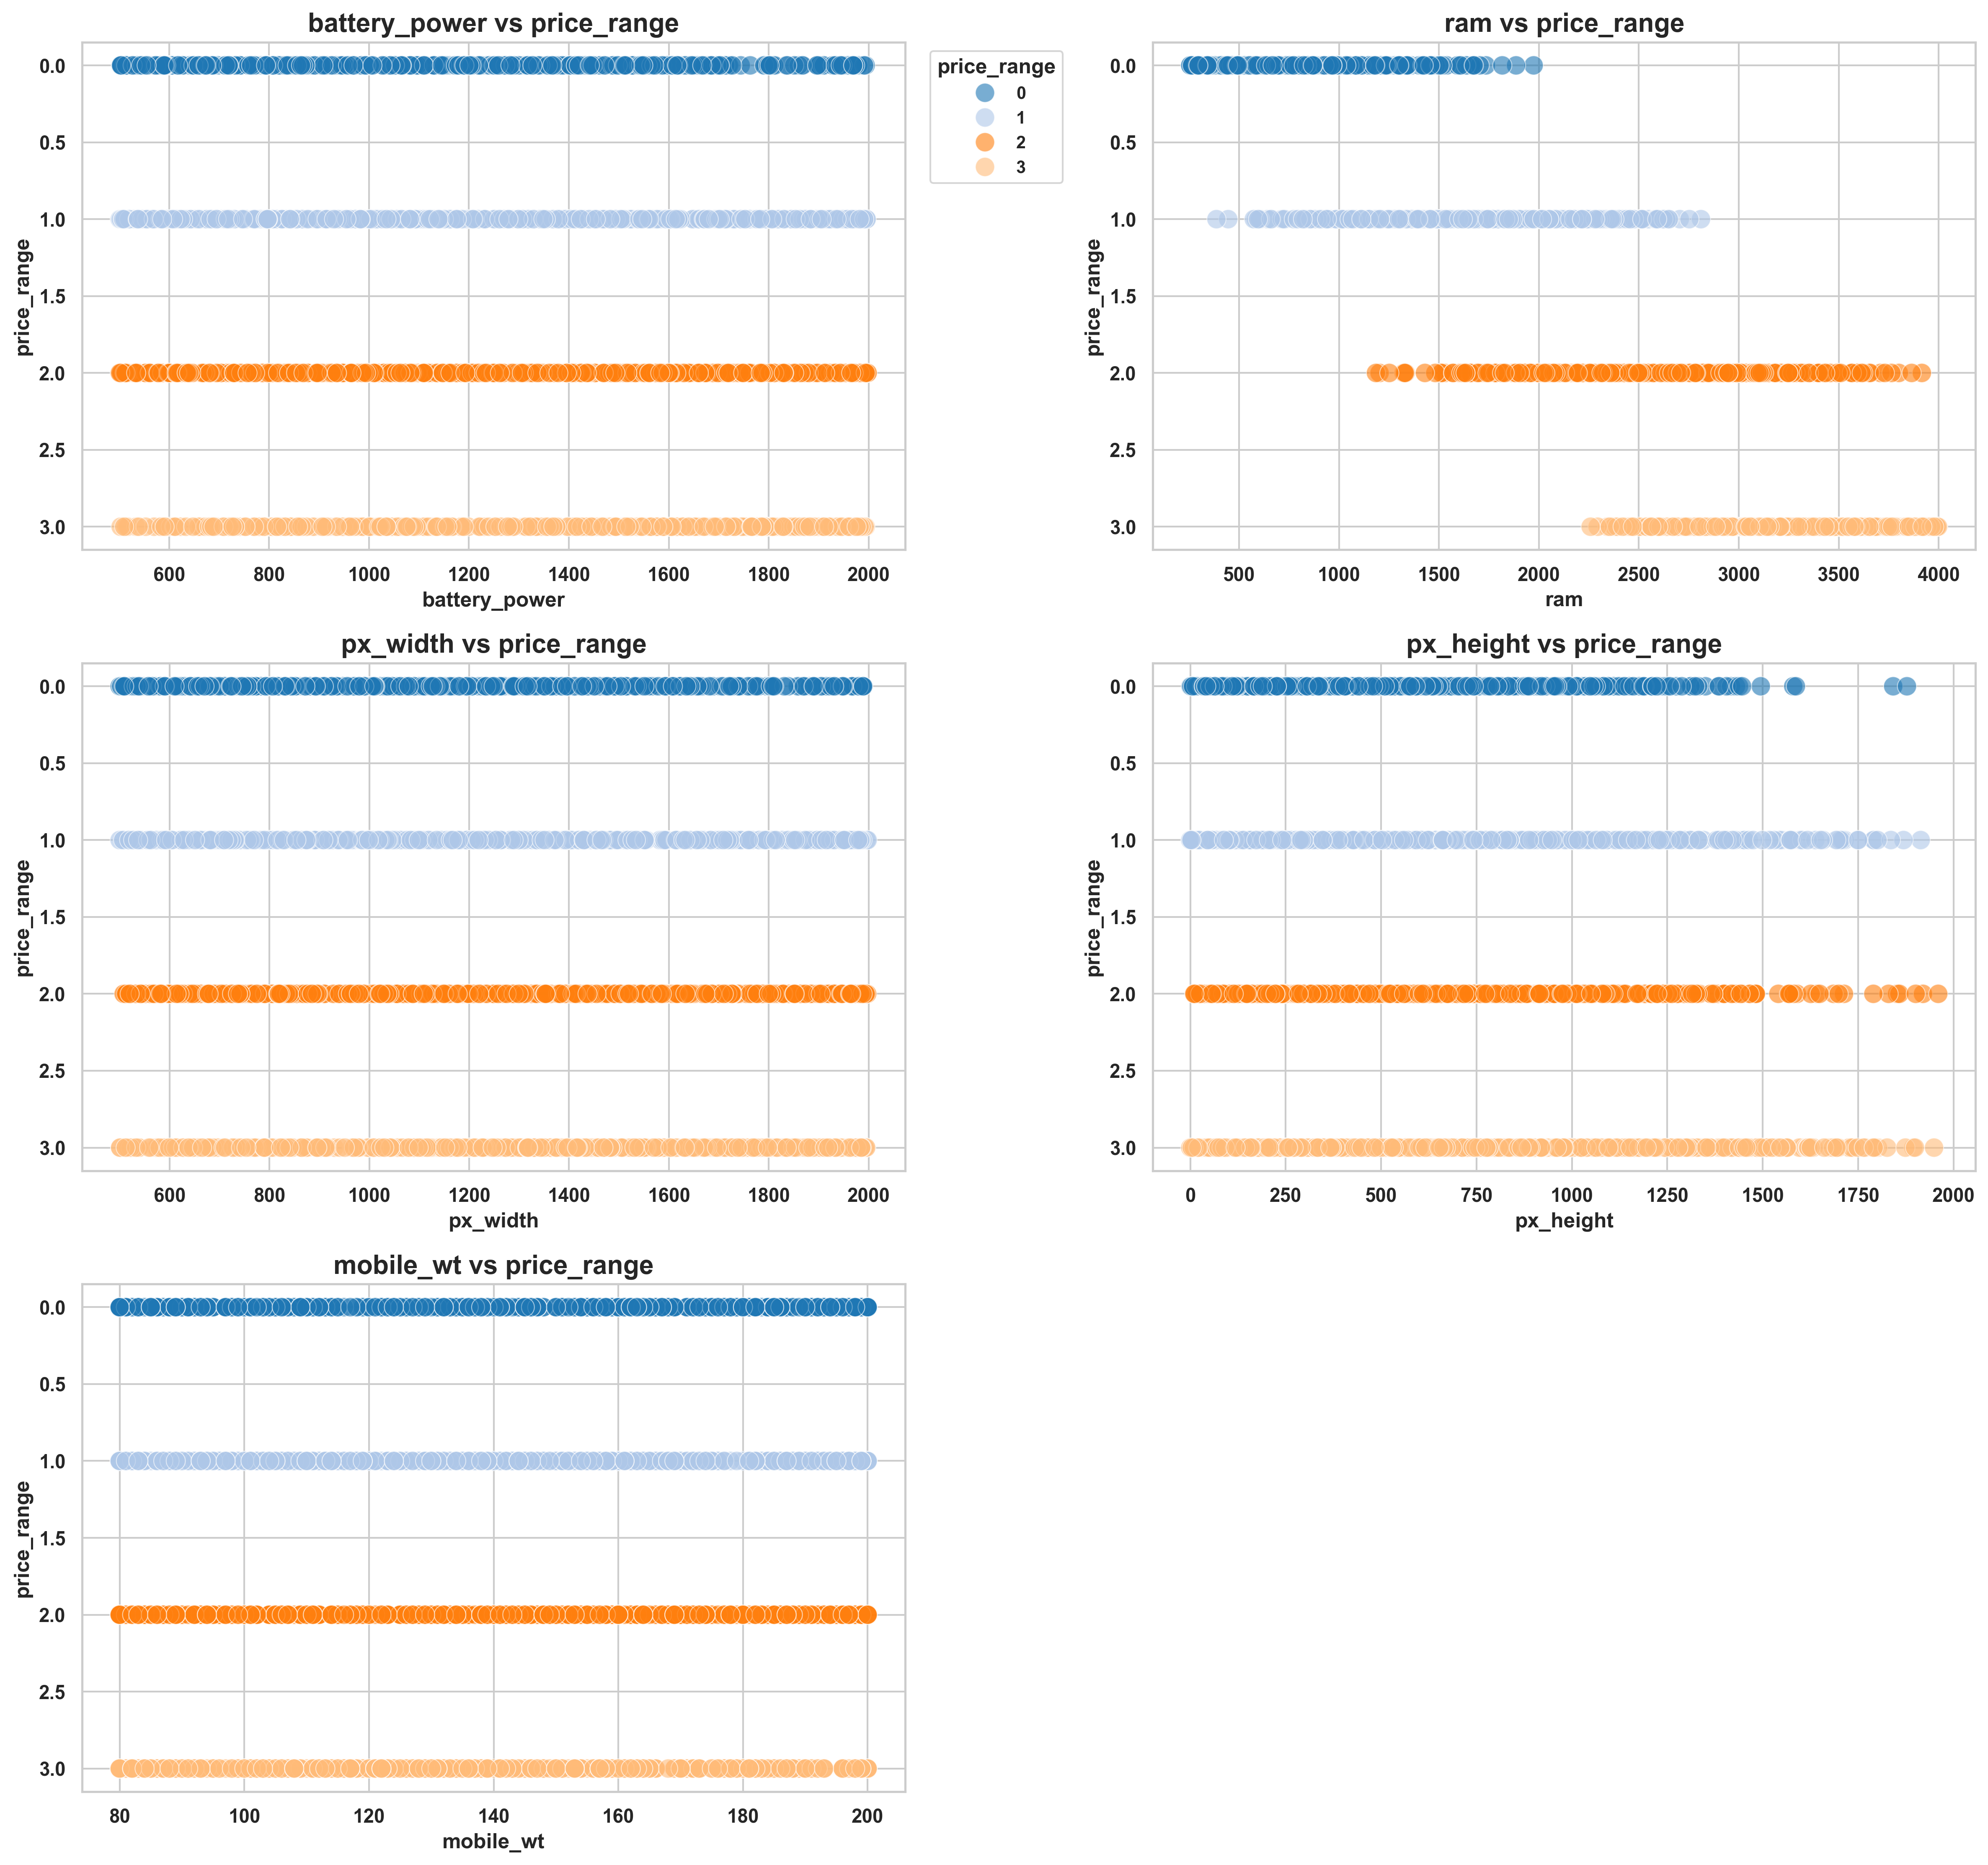

In [10]:
sns.set(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 300,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

train['price_range'] = train['price_range'].astype('category')
palette = sns.color_palette("tab20", len(train['price_range'].cat.categories))

pairs = [
    ('battery_power', 'price_range'),
    ('ram', 'price_range'),
    ('px_width', 'price_range'),
    ('px_height', 'price_range'),
    ('mobile_wt', 'price_range')
]

ncols = 2
nrows = (len(pairs) + 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

for idx, (ax, (x, y)) in enumerate(zip(axes, pairs)):
    sns.scatterplot(
        data=train,
        x=x, y=y,
        hue='price_range',
        palette=palette,
        ax=ax,
        alpha=0.6,
        edgecolor='white',
        linewidth=0.5,
        s=120
    )
    
    ax.set_title(f"{x} vs {y}", fontweight='bold')
    ax.set_xlabel(x, fontsize=12, fontweight='bold')
    ax.set_ylabel(y, fontsize=12, fontweight='bold')

    if idx == 0:
        ax.legend(title='price_range', bbox_to_anchor=(1.02, 1), loc='upper left')
    else:
        ax.get_legend().remove()

for j in range(len(pairs), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In this scatter plot we can see clear seperation in ram values between low and high ranges while features like screen resolution show overlapping trends.

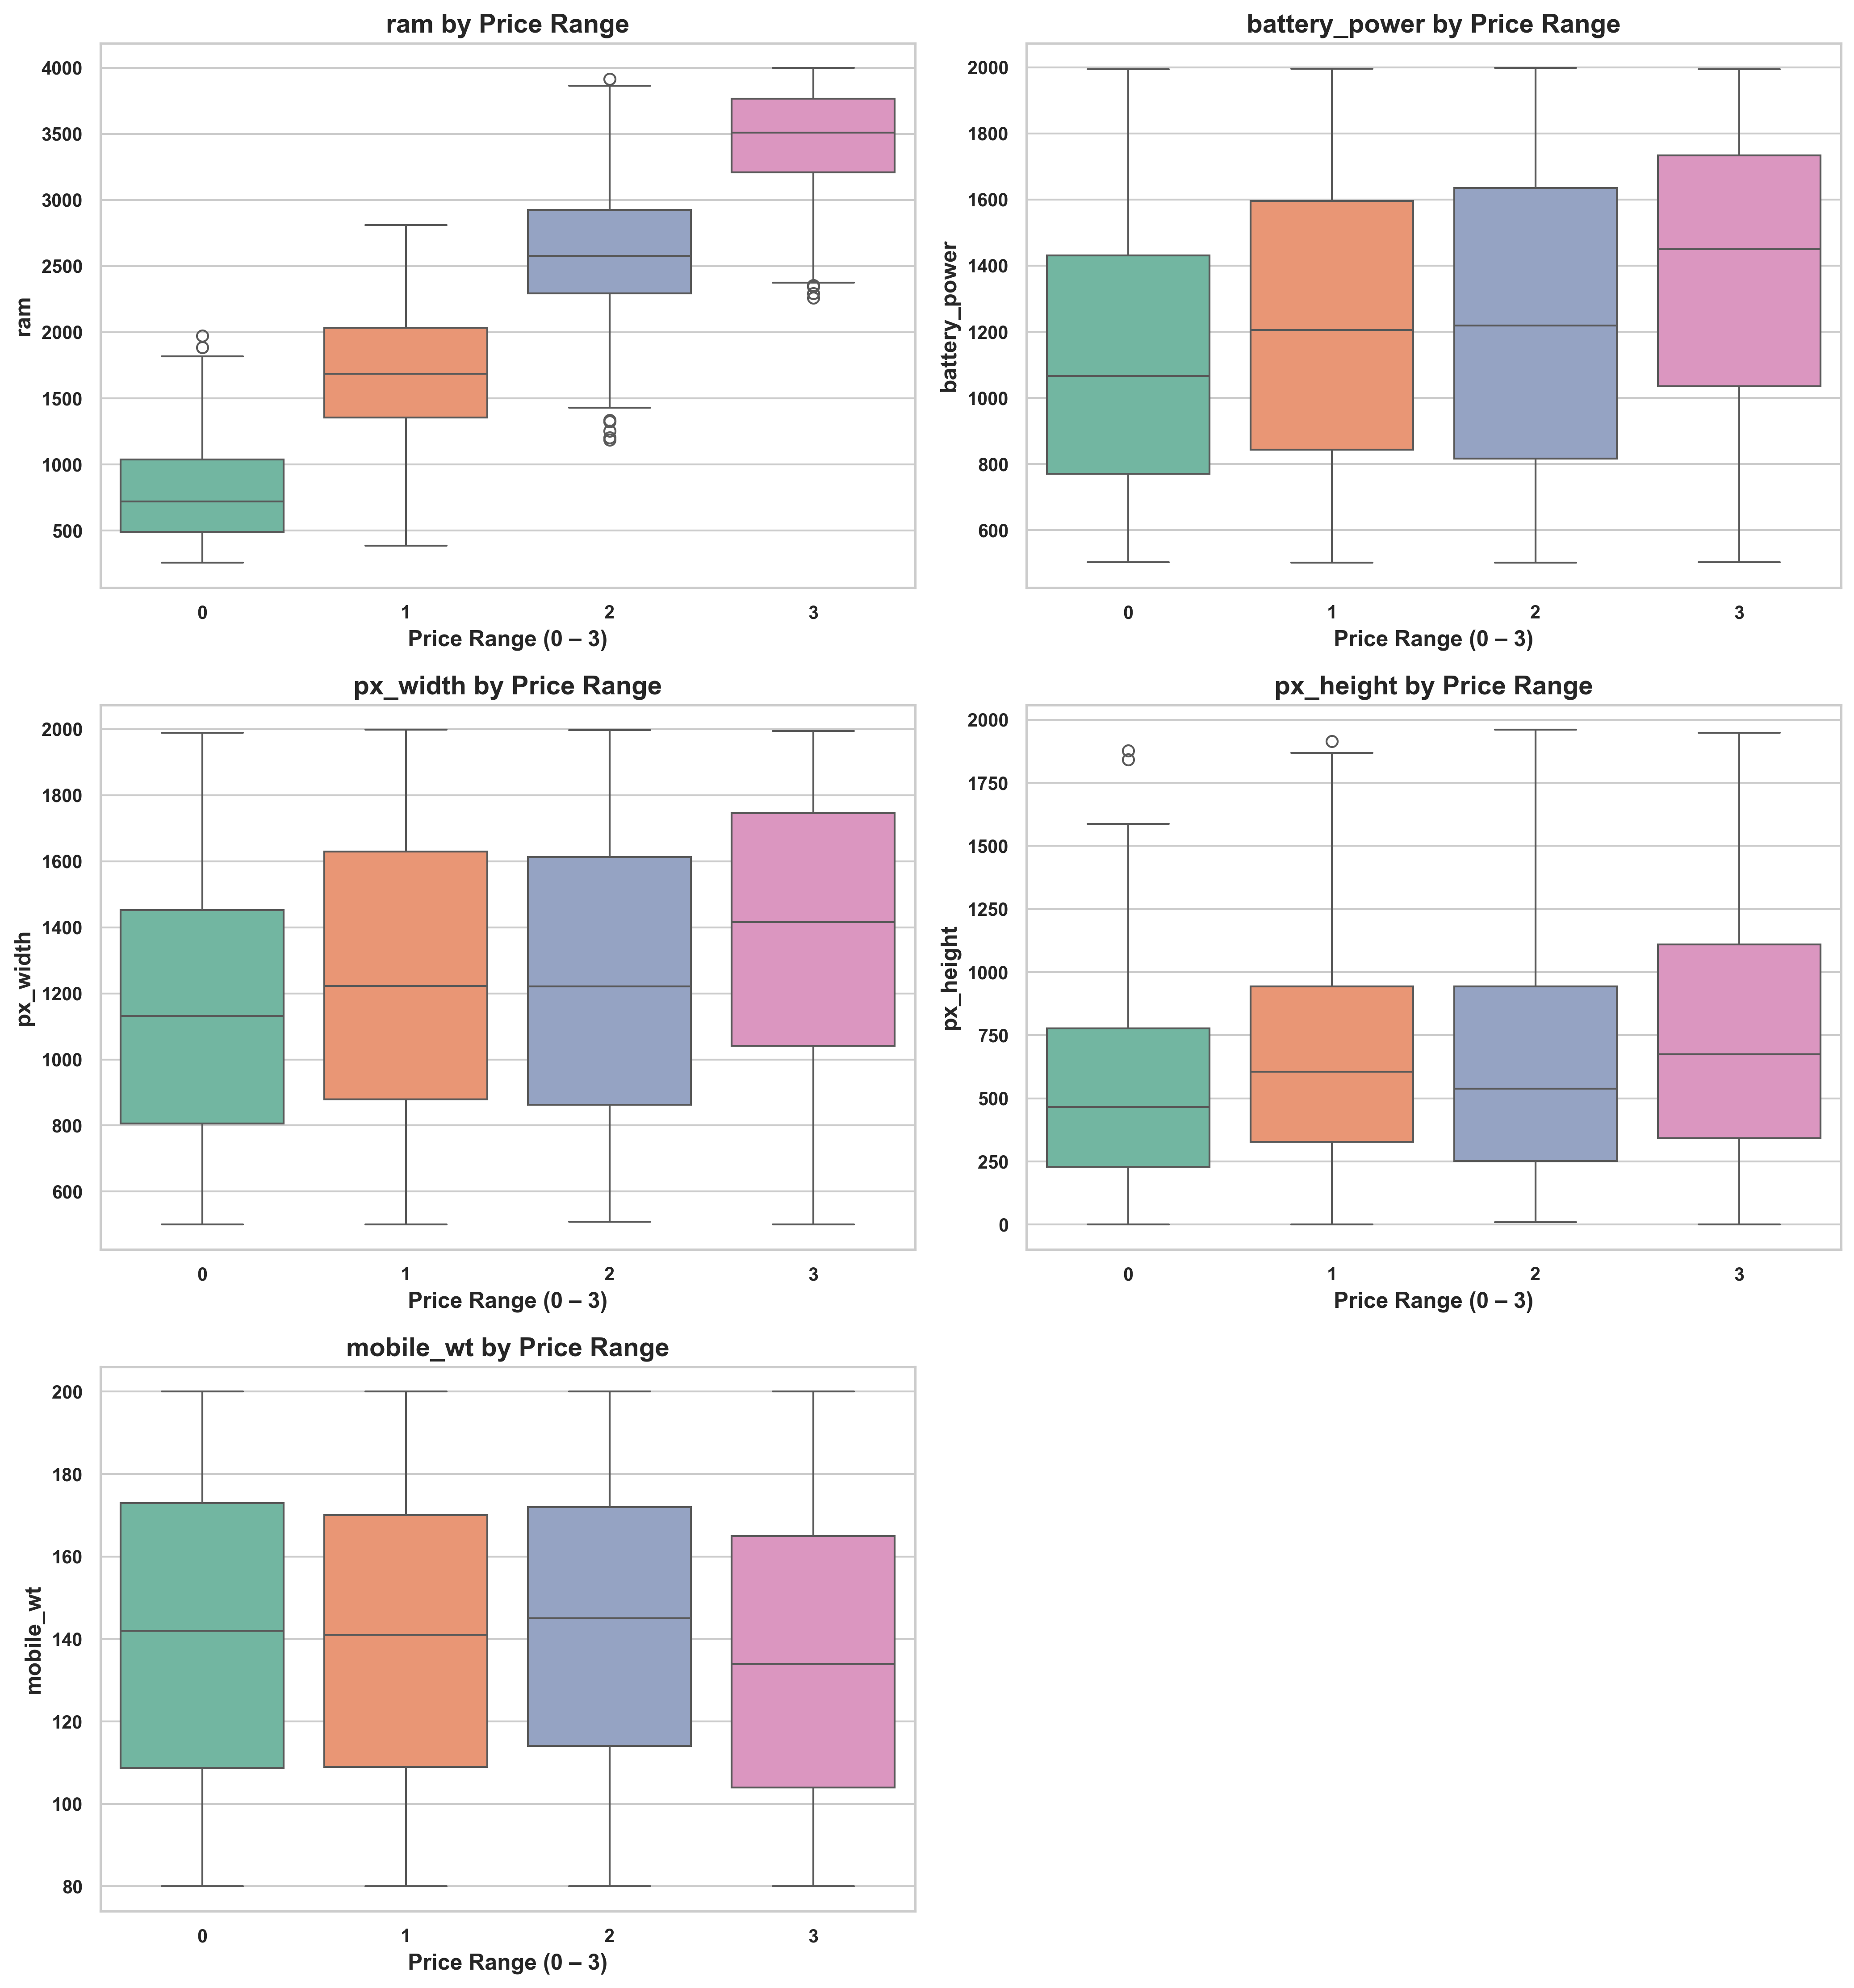

In [11]:
sns.set(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 300,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

features = [
    'ram',
    'battery_power',
    'px_width',
    'px_height',
    'mobile_wt'
]

train['price_range'] = train['price_range'].astype('category')

ncols = 2
nrows = (len(features) + 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 5))
axes = axes.flatten()

palette = sns.color_palette("Set2", len(train['price_range'].cat.categories))

for idx, (ax, feat) in enumerate(zip(axes, features)):
    sns.boxplot(
        data=train,
        x="price_range",
        y=feat,
        ax=ax,
        palette=palette
    )
    
    ax.set_title(f"{feat} by Price Range")
    ax.set_xlabel("Price Range (0 – 3)")
    ax.set_ylabel(feat)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Each box plot shows how the distribution of a feature changes from cheaper to more expensive ones

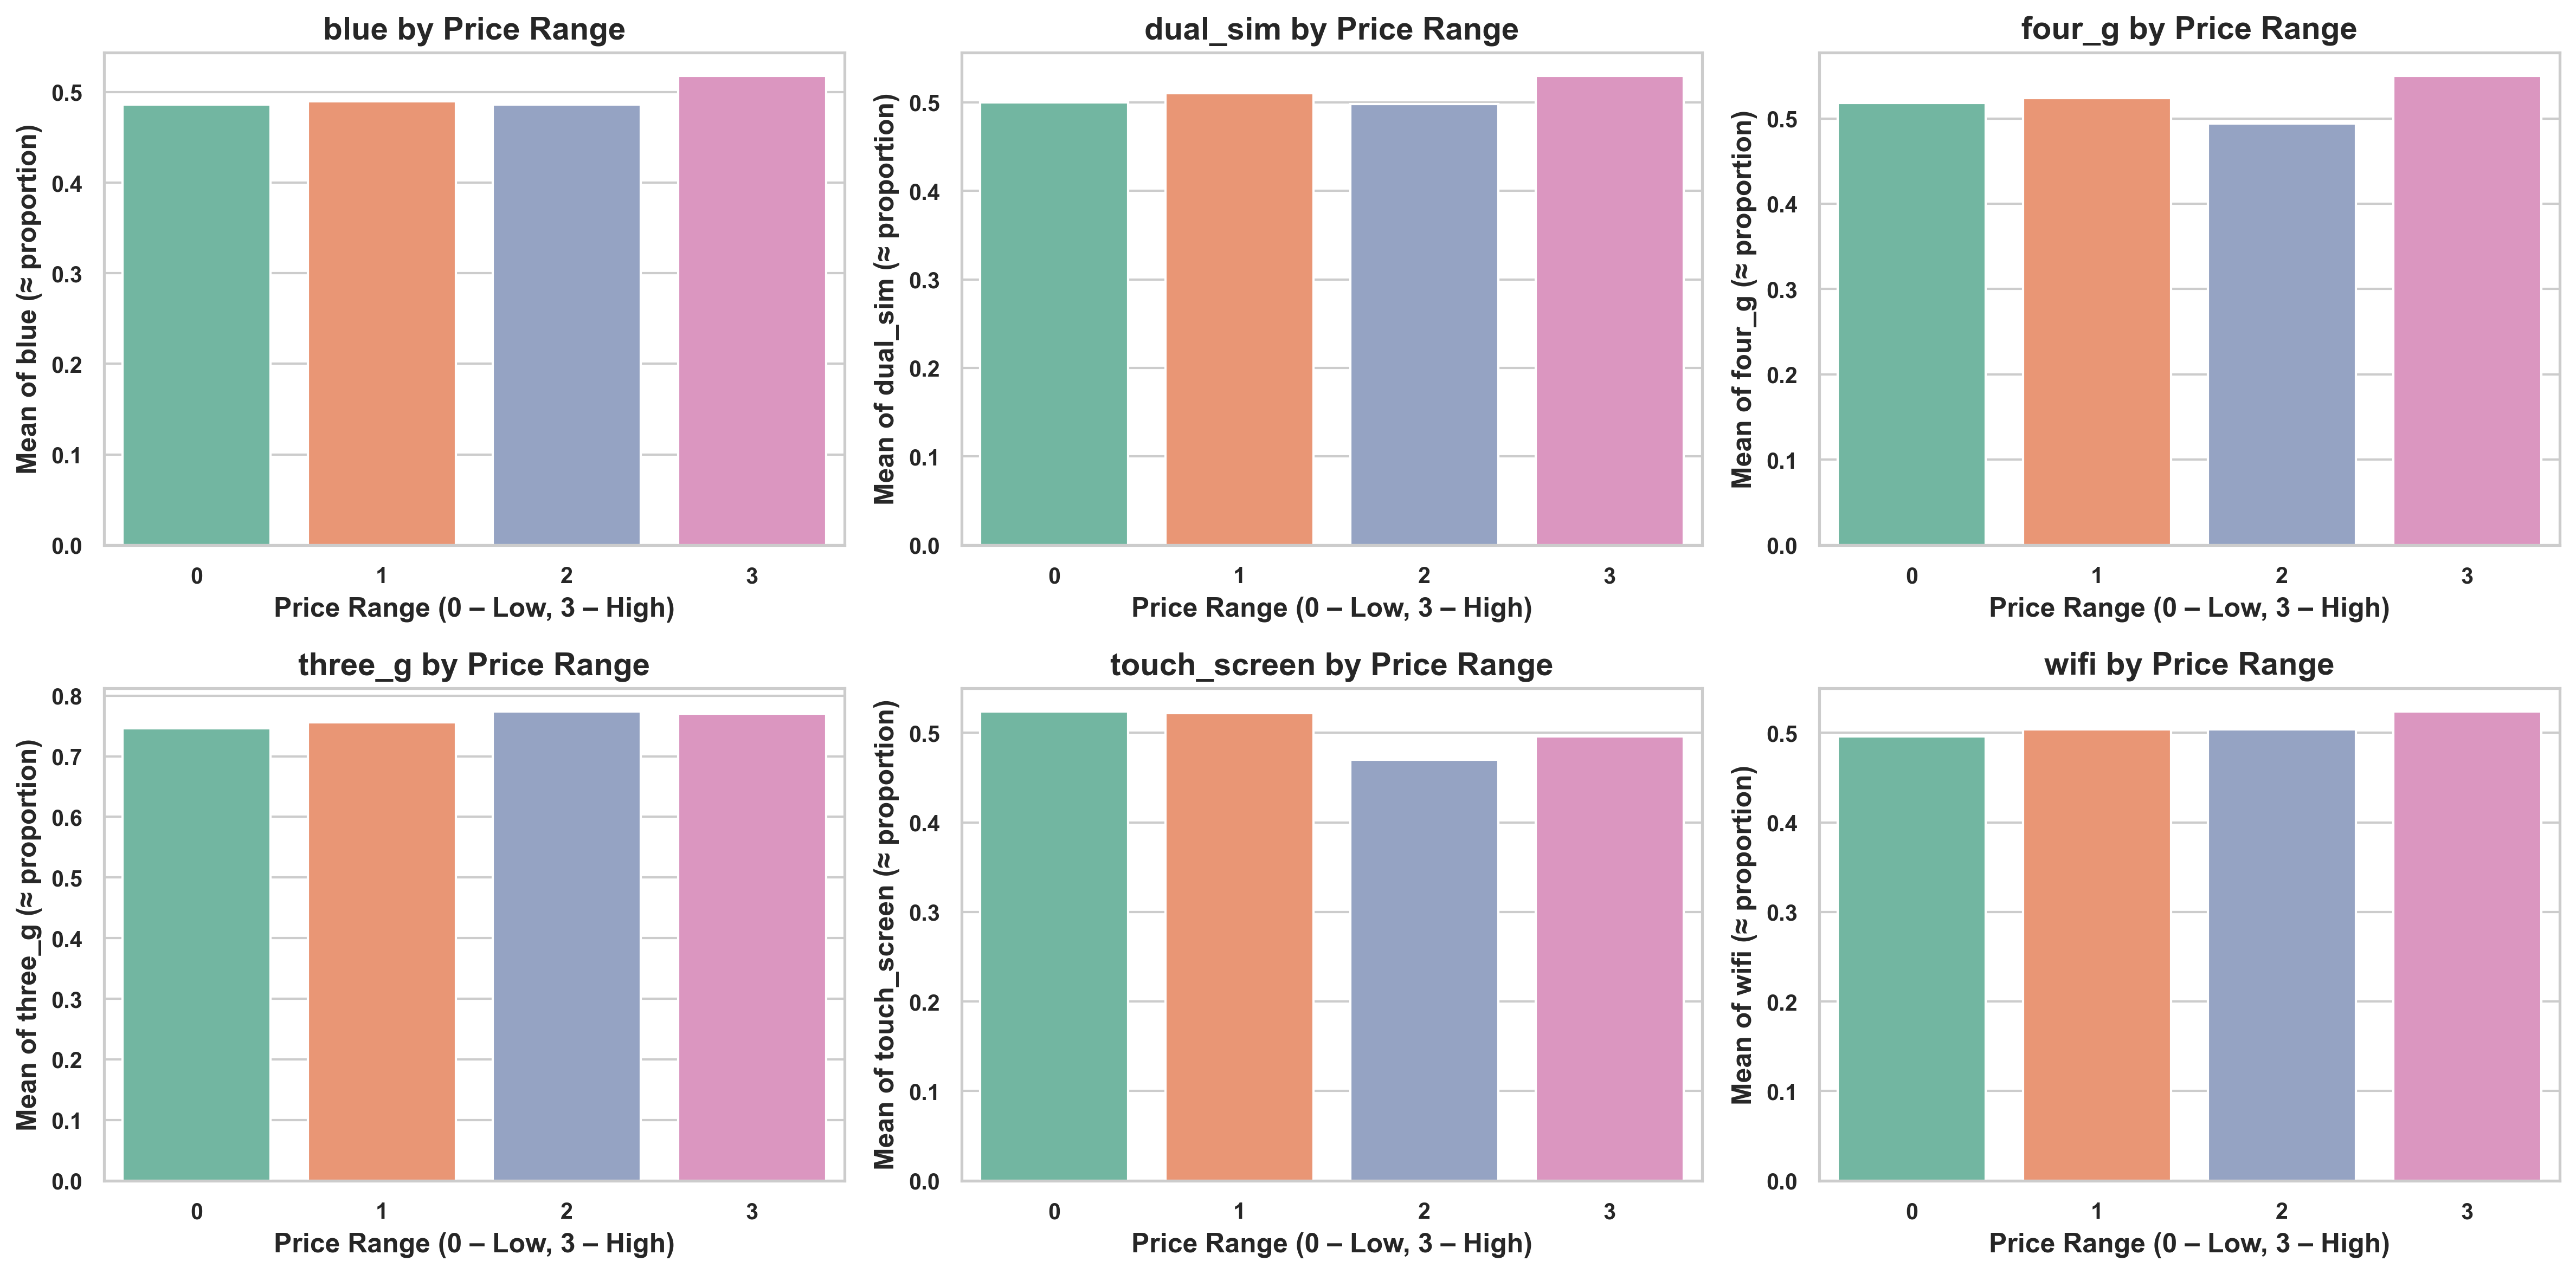

In [12]:
sns.set(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 300,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

train['price_range'] = train['price_range'].astype('category')

binary_features = [
    'blue',
    'dual_sim',
    'four_g',
    'three_g',
    'touch_screen',
    'wifi'
]

ncols = 3
nrows = (len(binary_features) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

palette = sns.color_palette("Set2", len(train['price_range'].cat.categories))

for ax, feat in zip(axes, binary_features):
    sns.barplot(
        data=train,
        x='price_range',
        y=feat,        
        ci=None,
        ax=ax,
        palette=palette
    )
    ax.set_title(f"{feat} by Price Range")
    ax.set_xlabel("Price Range (0 – Low, 3 – High)")
    ax.set_ylabel(f"Mean of {feat} (≈ proportion)")

for j in range(len(binary_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

For each binary feature the bars show how often the feature is present in each price

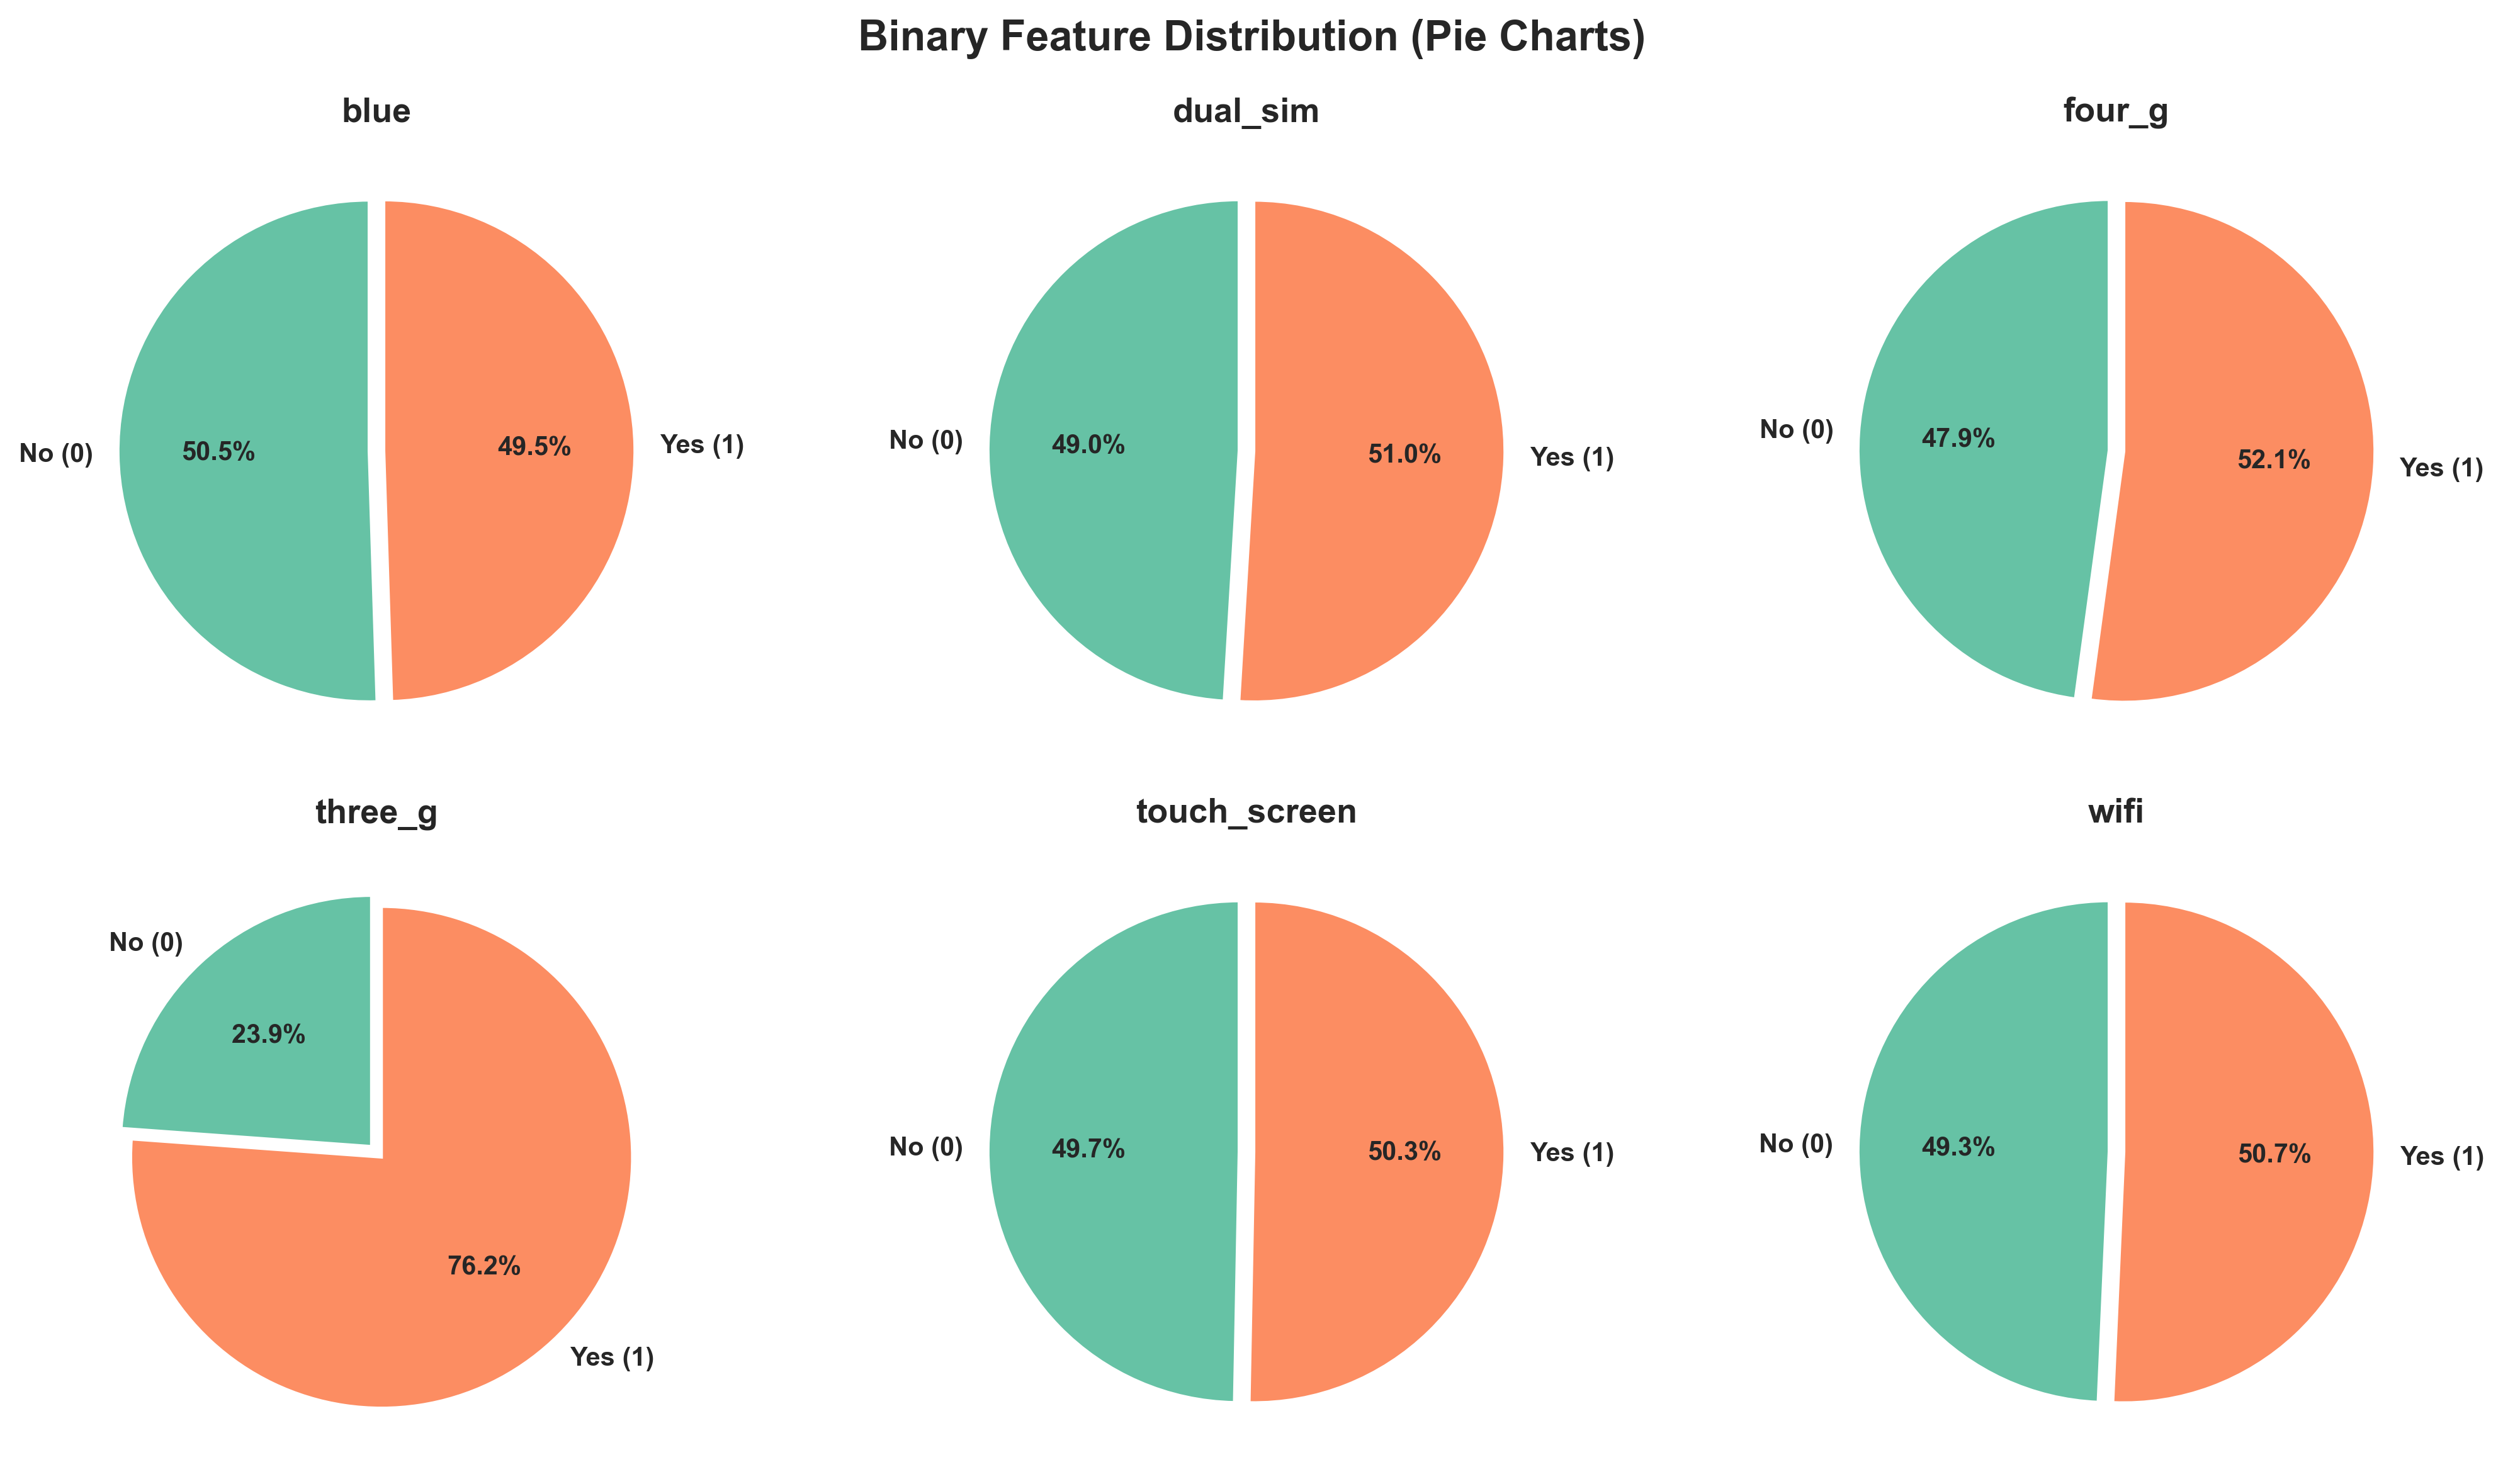

In [13]:
binary_feats = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

colors = sns.color_palette("Set2", 2)

ncols = 3
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 8))

axes = axes.flatten()

for ax, feat in zip(axes, binary_feats):
    counts = train[feat].value_counts().sort_index()
    labels = ['No (0)', 'Yes (1)']
    
    ax.pie(
        counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        explode=[0.03, 0.03],
        colors=colors,
        textprops={'fontsize': 10}
    )
    
    ax.set_title(f"{feat}", fontsize=13, fontweight='bold')

for j in range(len(binary_feats), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Binary Feature Distribution (Pie Charts)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

The pie charts indicte the baalance for each binary feature across all phones

In [14]:
logic_noise = pd.DataFrame(columns=['column', 'index', 'value'])

conditions = {
    'battery_power': lambda x: (x <= 0) | (x > 10000),
    'ram':           lambda x: (x <= 0) | (x < 64) | (x > 16384),
    'int_memory':    lambda x: (x <= 0) | (x > 2048),
    'n_cores':       lambda x: (x <= 0) | (x > 16),
    'clock_speed':   lambda x: (x <= 0) | (x > 5),

    'px_height':     lambda x: (x <= 0) | (x < 20) | (x > 5000),
    'px_width':      lambda x: (x <= 0) | (x < 200) | (x > 5000),

    'sc_h':          lambda x: (x <= 0) | (x > 20),
    'sc_w':          lambda x: (x <= 0),

    'mobile_wt':     lambda x: (x <= 0) | (x < 70) | (x > 350),
    'm_dep':         lambda x: (x <= 0),

    'fc':            lambda x: (x < 0) | (x > 100),
    'pc':            lambda x: (x < 0) | (x > 100),

    'talk_time':     lambda x: (x <= 0) | (x > 72),

    'blue':          lambda x: ~x.isin([0, 1]),
    'dual_sim':      lambda x: ~x.isin([0, 1]),
    'three_g':       lambda x: ~x.isin([0, 1]),
    'four_g':        lambda x: ~x.isin([0, 1]),
    'touch_screen':  lambda x: ~x.isin([0, 1]),
    'wifi':          lambda x: ~x.isin([0, 1]),

    'price_range':   lambda x: ~x.isin([0, 1, 2, 3]),
}

for col, condition in conditions.items():
    if col in train.columns:
        mask = condition(train[col])
        if mask.sum() > 0:
            temp_df = pd.DataFrame({
                'column': col,
                'index': train[mask].index,
                'value': train.loc[mask, col].values
            })
            logic_noise = pd.concat([logic_noise, temp_df], ignore_index=True)

print("number of logic-based noisy values:", len(logic_noise))
print(logic_noise.head())

number of logic-based noisy values: 207
      column index value
0  px_height    73     4
1  px_height   322    19
2  px_height   338    14
3  px_height   347    13
4  px_height   468     6


In [15]:
for col, group in logic_noise.groupby('column'):
    indices = group['index'].values
    train.loc[indices, col] = np.nan  

train = train.dropna(subset=logic_noise['column'].unique()).reset_index(drop=True)

In [16]:
train

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20.0,756,2549,9,7.0,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905.0,1988,2631,17,3.0,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263.0,1716,2603,11,2.0,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216.0,1786,2769,16,8.0,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208.0,1212,1411,8,2.0,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1794,794,1,0.5,1,0,1,2,0.8,106,6,...,1222.0,1890,668,13,4.0,19,1,1,0,0
1795,1965,1,2.6,1,0,0,39,0.2,187,4,...,915.0,1965,2032,11,10.0,16,1,1,1,2
1796,1911,0,0.9,1,1,1,36,0.7,108,8,...,868.0,1632,3057,9,1.0,5,1,1,0,3
1797,1512,0,0.9,0,4,1,46,0.1,145,5,...,336.0,670,869,18,10.0,19,1,1,1,0


In [17]:
logic_noise_test = pd.DataFrame(columns=['column', 'index', 'value'])

for col, condition in conditions.items():
    if col in test.columns:
        mask = condition(test[col])
        if mask.sum() > 0:
            temp_df = pd.DataFrame({
                'column': col,
                'index': test[mask].index,
                'value': test.loc[mask, col].values
            })
            logic_noise_test = pd.concat([logic_noise_test, temp_df], ignore_index=True)

print("number of logic-based noisy values in TEST:", len(logic_noise_test))
print(logic_noise_test['column'].value_counts())
logic_noise_test.head()

number of logic-based noisy values in TEST: 136
column
sc_w         112
px_height     24
Name: count, dtype: int64


,column,index,value
0,px_height,62,19
1,px_height,214,13
2,px_height,282,3
3,px_height,293,16
4,px_height,309,12


In [18]:
for col, group in logic_noise_test.groupby('column'):
    indices = group['index'].values
    test.loc[indices, col] = np.nan

test = test.dropna(subset=logic_noise_test['column'].unique()).reset_index(drop=True)

Flagged physically impossible or highly unrealistic values as logic noises and cleaned them from both data frames

In [19]:
X = train.drop('price_range', axis=1)
y = train['price_range']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1 )

In [21]:
clf = DecisionTreeClassifier(max_depth=3)
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [22]:
print('Accuracy: ', metrics.accuracy_score(y_test, y_pred))

Accuracy:  0.7907407407407407


In [23]:
param_dt = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

In [24]:
dt = DecisionTreeClassifier(random_state=1)

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_dt,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


,estimator,DecisionTreeC...andom_state=1)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [25]:
cv_res = grid_dt.cv_results_

df_dt = pd.DataFrame({
    "mean_score": cv_res["mean_test_score"],
    "std_score":  cv_res["std_test_score"],
    "max_depth":  cv_res["param_max_depth"],
    "min_samples_split": cv_res["param_min_samples_split"],
    "min_samples_leaf":  cv_res["param_min_samples_leaf"],
    "criterion": cv_res["param_criterion"],
})

df_dt = df_dt.sort_values("mean_score", ascending=False).reset_index(drop=True)
df_dt.head()

,mean_score,std_score,max_depth,min_samples_split,min_samples_leaf,criterion
0,0.842731,0.010248,10,2,2,entropy
1,0.842731,0.010248,20,2,2,entropy
2,0.842731,0.010248,None,2,2,entropy
3,0.842731,0.010248,15,2,2,entropy
4,0.840353,0.009465,15,5,2,entropy


In [26]:
def highlight_best_each_column_dt(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            max_val = df[col].max()
            styles.loc[df[col] == max_val, col] = "background-color: yellow"
    return styles

best_idx_dt = df_dt["mean_score"].idxmax()

def highlight_best_row_dt(row):
    return ["background-color: orange" if row.name == best_idx_dt else "" for _ in row]

df_dt_style = (
    df_dt
    .style
    .apply(highlight_best_each_column_dt, axis=None)
    .apply(highlight_best_row_dt, axis=1)
)

df_dt_style

,mean_score,std_score,max_depth,min_samples_split,min_samples_leaf,criterion
0,0.842731,0.010248,10,2,2,entropy
1,0.842731,0.010248,20,2,2,entropy
2,0.842731,0.010248,None,2,2,entropy
3,0.842731,0.010248,15,2,2,entropy
4,0.840353,0.009465,15,5,2,entropy
5,0.840353,0.009465,10,5,2,entropy
6,0.840353,0.009465,20,5,2,entropy
7,0.840353,0.009465,None,5,2,entropy
8,0.840350,0.010157,10,2,4,entropy
9,0.840350,0.010157,10,5,4,entropy


In [ ]:
best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)

acc  = metrics.accuracy_score(y_test, y_pred_dt)
f1   = metrics.f1_score(y_test, y_pred_dt, average="macro")
cm   = metrics.confusion_matrix(y_test, y_pred_dt)

print("Best params:", grid_dt.best_params_)
print("Accuracy :", acc)
print("F1 macro:", f1)
print("\nClassification report:\n")
print(metrics.classification_report(y_test, y_pred_dt))
print("Confusion matrix:\n", cm)

Defined hypermarameter grid for our decision tree and run gridsearch for it using cross validation to find the best parameter and finally highlighted the best values in each numeric column and the overall best row

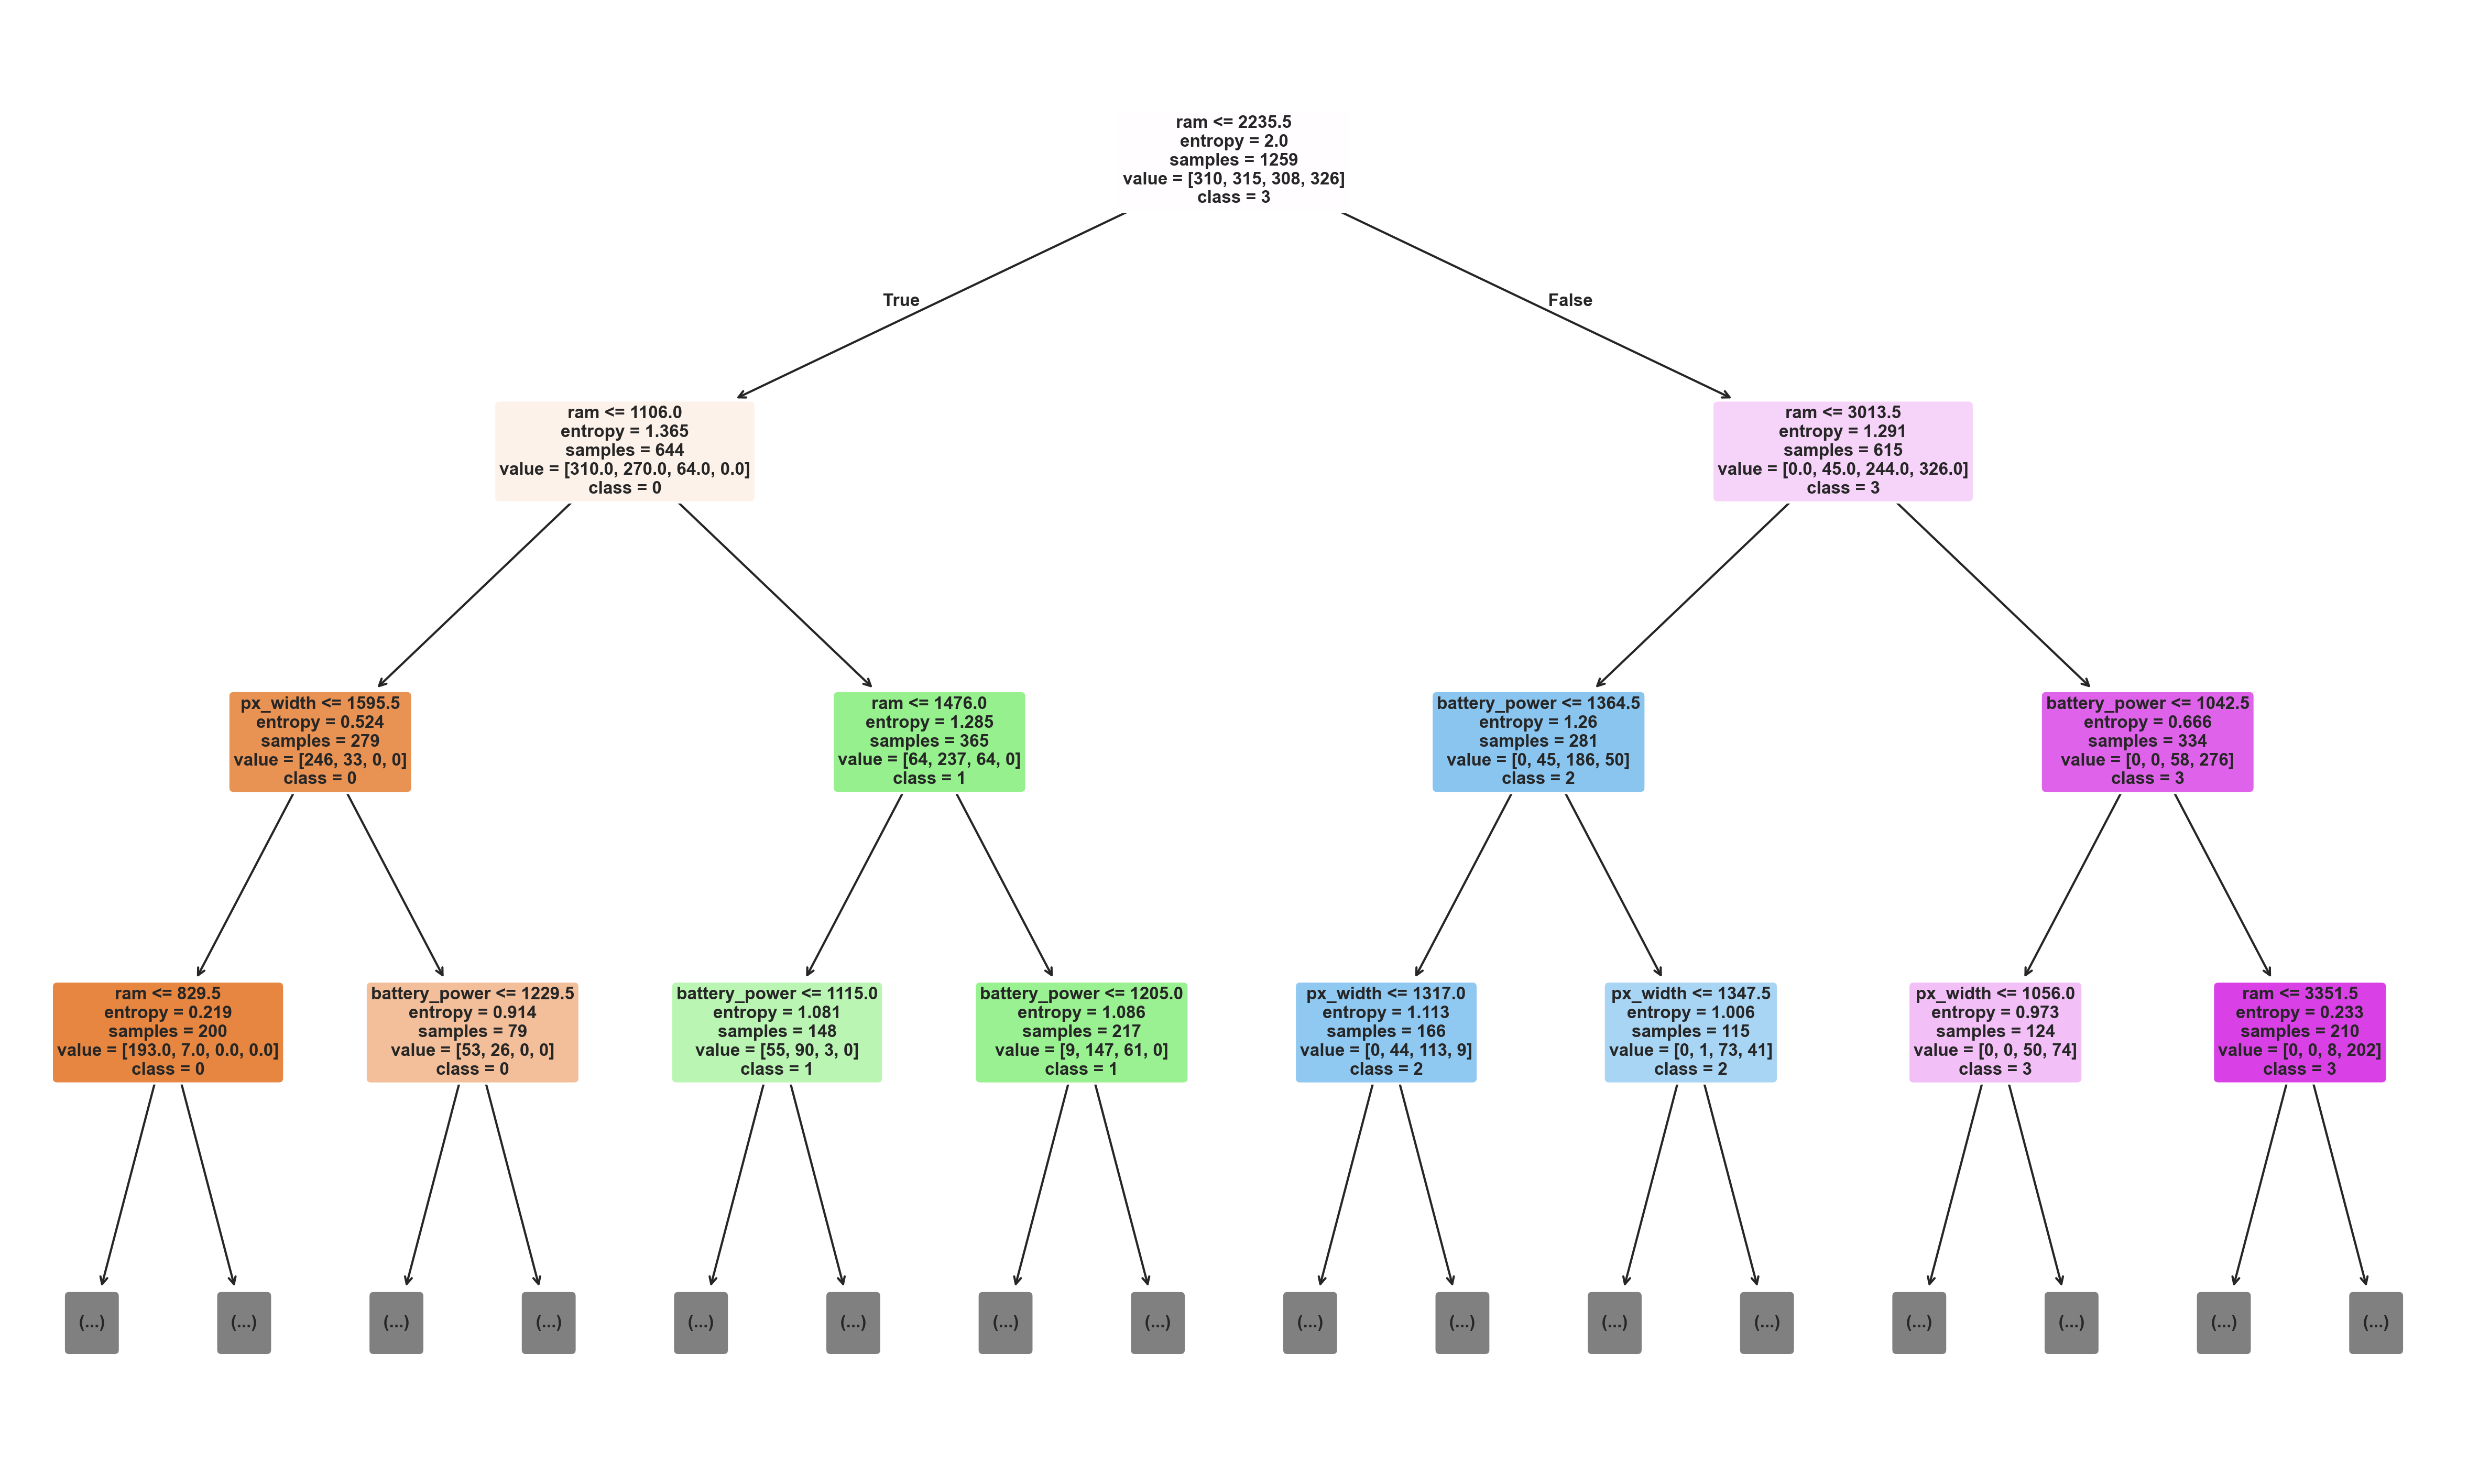

In [28]:
feature_names = train.drop("price_range", axis=1).columns.tolist()

class_names = [str(c) for c in sorted(train["price_range"].unique())]

plt.figure(figsize=(20, 12))
tree.plot_tree(
    best_dt,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.show()

In [29]:
clf = RandomForestClassifier(n_estimators=50, max_depth=3)
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [30]:
print('Accuracy: ', metrics.accuracy_score(y_test, y_pred))

Accuracy:  0.8296296296296296


In [31]:
param_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]  
}

In [32]:
rf = RandomForestClassifier(random_state=1)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,RandomForestC...andom_state=1)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [33]:
cv_res_rf = grid_rf.cv_results_

df_rf = pd.DataFrame({
    "mean_score": cv_res_rf["mean_test_score"],
    "std_score":  cv_res_rf["std_test_score"],
    "n_estimators":      cv_res_rf["param_n_estimators"],
    "max_depth":         cv_res_rf["param_max_depth"],
    "min_samples_split": cv_res_rf["param_min_samples_split"],
    "min_samples_leaf":  cv_res_rf["param_min_samples_leaf"],
    "max_features":      cv_res_rf["param_max_features"]
})

df_rf = df_rf.sort_values("mean_score", ascending=False).reset_index(drop=True)
df_rf.head()

,mean_score,std_score,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features
0,0.874505,0.020004,200,None,5,1,sqrt
1,0.874505,0.020004,200,20,5,1,sqrt
2,0.872115,0.015400,200,20,5,2,sqrt
3,0.871324,0.010849,100,None,5,1,sqrt
4,0.871321,0.016989,100,20,5,2,sqrt


In [34]:
def highlight_best_each_column_rf(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            max_val = df[col].max()
            styles.loc[df[col] == max_val, col] = "background-color: yellow"
    return styles

best_idx_rf = df_rf["mean_score"].idxmax()

def highlight_best_row_rf(row):
    return ["background-color: orange" if row.name == best_idx_rf else "" for _ in row]

df_rf_style = (
    df_rf
    .style
    .apply(highlight_best_each_column_rf, axis=None)
    .apply(highlight_best_row_rf, axis=1)
)

df_rf_style

,mean_score,std_score,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features
0,0.874505,0.020004,200,None,5,1,sqrt
1,0.874505,0.020004,200,20,5,1,sqrt
2,0.872115,0.015400,200,20,5,2,sqrt
3,0.871324,0.010849,100,None,5,1,sqrt
4,0.871321,0.016989,100,20,5,2,sqrt
5,0.871321,0.016989,100,None,5,2,sqrt
6,0.871321,0.014810,200,None,5,2,sqrt
7,0.870527,0.011167,100,20,5,1,sqrt
8,0.870524,0.021581,200,10,5,2,sqrt
9,0.869731,0.013212,200,10,5,1,sqrt


In [35]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

acc_rf  = metrics.accuracy_score(y_test, y_pred_rf)
f1_rf   = metrics.f1_score(y_test, y_pred_rf, average="macro")
cm_rf   = confusion_matrix(y_test, y_pred_rf)

print("Best params (Random Forest):")
print(grid_rf.best_params_)
print()
print("Accuracy :", acc_rf)
print("F1 macro:", f1_rf)
print()
print("Classification report:\n")
print(classification_report(y_test, y_pred_rf))
print("Confusion matrix:\n", cm_rf)

Best params (Random Forest):
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Accuracy : 0.9
F1 macro: 0.9004497358021522

Classification report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       134
           1       0.83      0.90      0.86       133
           2       0.90      0.78      0.84       144
           3       0.92      0.95      0.94       129

    accuracy                           0.90       540
   macro avg       0.90      0.90      0.90       540
weighted avg       0.90      0.90      0.90       540

Confusion matrix:
 [[130   4   0   0]
 [  7 120   6   0]
 [  0  21 113  10]
 [  0   0   6 123]]


Defined hypermarameter grid for our random forest and run gridsearch for it using cross validation to find the best parameter and finally highlighted the best values in each numeric column and the overall best row

In [36]:
clf = SVC(kernel="linear")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [37]:
print("Accuracy :", metrics.accuracy_score(y_test, y_pred))

Accuracy : 0.9629629629629629


In [38]:
param_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],  
    "gamma": ["scale", "auto"]    
}

In [39]:
svm_base = SVC()   

grid_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [40]:
cv_res_svm = grid_svm.cv_results_

df_svm = pd.DataFrame({
    "mean_score": cv_res_svm["mean_test_score"],
    "std_score":  cv_res_svm["std_test_score"],
    "C":          cv_res_svm["param_C"],
    "kernel":     cv_res_svm["param_kernel"],
    "gamma":      cv_res_svm["param_gamma"],
})

df_svm = df_svm.sort_values("mean_score", ascending=False).reset_index(drop=True)
df_svm.head()

,mean_score,std_score,C,kernel,gamma
0,0.976956,0.009562,10.0,linear,scale
1,0.976956,0.009562,10.0,linear,auto
2,0.976162,0.010073,1.0,linear,scale
3,0.976162,0.010073,1.0,linear,auto
4,0.975368,0.007736,0.1,linear,scale


In [41]:
def highlight_best_each_column_svm(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            max_val = df[col].max()
            styles.loc[df[col] == max_val, col] = "background-color: yellow"
    return styles

best_idx_svm = df_svm["mean_score"].idxmax()

def highlight_best_row_svm(row):
    return ["background-color: orange" if row.name == best_idx_svm else "" for _ in row]

df_svm_style = (
    df_svm
    .style
    .apply(highlight_best_each_column_svm, axis=None)
    .apply(highlight_best_row_svm, axis=1)
)

df_svm_style

,mean_score,std_score,C,kernel,gamma
0,0.976956,0.009562,10.000000,linear,scale
1,0.976956,0.009562,10.000000,linear,auto
2,0.976162,0.010073,1.000000,linear,scale
3,0.976162,0.010073,1.000000,linear,auto
4,0.975368,0.007736,0.100000,linear,scale
5,0.975368,0.007736,0.100000,linear,auto
6,0.961867,0.011695,10.000000,rbf,scale
7,0.953130,0.011644,1.000000,rbf,scale
8,0.887200,0.012565,0.100000,rbf,scale
9,0.258936,0.001537,0.100000,rbf,auto


In [ ]:
from sklearn.metrics import f1_score
best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test)

acc_svm  = metrics.accuracy_score(y_test, y_pred_svm)
f1_svm   = f1_score(y_test, y_pred_svm, average="macro")
cm_svm   = confusion_matrix(y_test, y_pred_svm)

print("Best params (SVM):", grid_svm.best_params_)
print("Accuracy :", acc_svm)
print("F1 macro:", f1_svm)
print("\nClassification report:\n", classification_report(y_test, y_pred_svm))
print("Confusion matrix:\n", cm_svm)

Defined hypermarameter grid for our SVM and run gridsearch for it using cross validation to find the best parameter and finally highlighted the best values in each numeric column and the overall best row

In [43]:
print("Train acc:", best_svm.score(X_train, y_train))
print("Test  acc:", best_svm.score(X_test,  y_test))

Train acc: 0.9968228752978554
Test  acc: 0.9592592592592593


Checked for overfitting

In [44]:
X_test_final = test[X_train.columns]

In [46]:
dt_final = DecisionTreeClassifier(**grid_dt.best_params_)
dt_final.fit(X_train, y_train)

rf_final = RandomForestClassifier(**grid_rf.best_params_)
rf_final.fit(X_train, y_train)

svm_final = SVC(**grid_svm.best_params_)
svm_final.fit(X_train, y_train)

,C,10
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [47]:
y_pred_dt  = dt_final.predict(X_test_final)
y_pred_rf  = rf_final.predict(X_test_final)
y_pred_svm = svm_final.predict(X_test_final)

In [ ]:
preds_all = pd.DataFrame({
    "id": test["id"].values,        
    "pred_dt":  y_pred_dt,
    "pred_rf":  y_pred_rf,
    "pred_svm": y_pred_svm
})

display(preds_all)

Finally refitting the final decision tree, random forest and svm models using the best found parameters and predicting the price_range on the test set